<a href="https://colab.research.google.com/github/frostd1022/neur_256_spring26/blob/main/Homework_6%20-%20Frost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

David Frost

*Intro to Neural Data Analysis*

**4/3/26**

In [37]:
#Importing relevant modules

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as pearsonr

In [11]:

#Importing data as numpy arrays

url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv'
shock_index = np.loadtxt(url1, delimiter = ',')

url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv'
tone_index = np.loadtxt(url2, delimiter = ',')

url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv'
fear_traces = np.loadtxt(url3, delimiter=',')

url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv'
extinction_predictors = np.loadtxt(url4, delimiter=',')



In [7]:
#Creating two new variables in conditioning traces and exctinction traces, conditioning traces contains the first 10458 samples as rows and extinction traces contain the remaining 10459 samples as rows

conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10458:, :]

In [9]:
#printing the size of conditioning_traces and extinction_traces

print(conditioning_traces.size)
print(extinction_traces.size)

658854
895230


In [13]:
#Made time_conditioning and time_extinction variables. Used the sampling rate and made sure I had a length of treocrding session and length equal to the number of samples for each session

sampling_rate = 15

time_conditioning = np.linspace(0, conditioning_traces.shape[0] / sampling_rate, conditioning_traces.shape[0])
time_extinction = np.linspace(0, extinction_traces.shape[0] / sampling_rate, extinction_traces.shape[0])

In [14]:
#This was to help me interpret the previous cells to be able to state the number of ROIs and other relevant information.

print('Number of ROIs:', conditioning_traces.shape[1])
print('Conditioning length (s):', conditioning_traces.shape[0] / 15)
print('Conditioning length (min):', conditioning_traces.shape[0] / 15 / 60)
print('Extinction length (s):', extinction_traces.shape[0] / 15)
print('Extinction length (min):', extinction_traces.shape[0] / 15 / 60)

Number of ROIs: 63
Conditioning length (s): 697.2
Conditioning length (min): 11.620000000000001
Extinction length (s): 947.3333333333334
Extinction length (min): 15.78888888888889


Number of ROIs: 63

Conditioning length (s): 697.2

Conditioning length (min): 11.
62

Extinction length (s): 947.33

Extinction length (min): 15.78888888888889

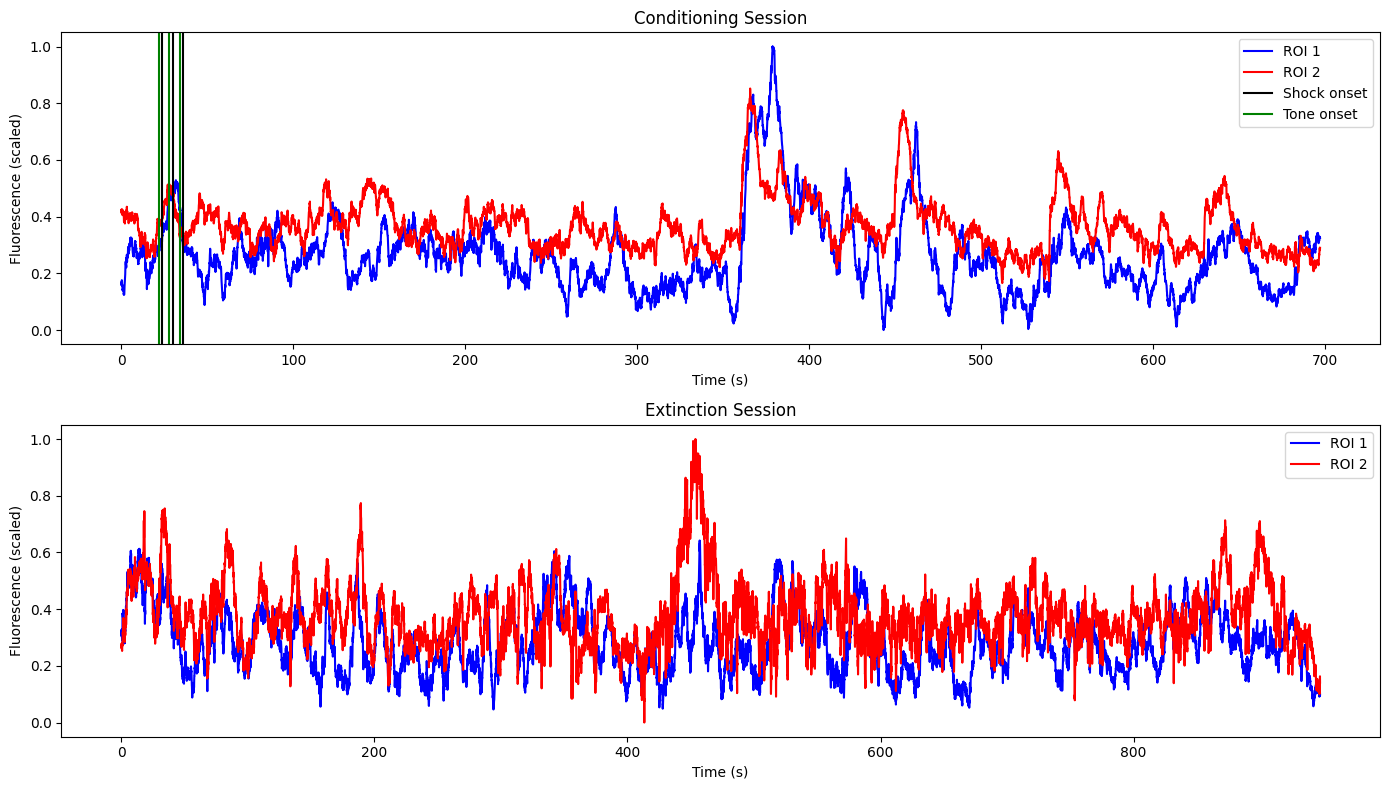

In [18]:
#Plotted the first and second ROIs from conditioning_traces in a subplot and the ROIs from extinction_traces in another. Labeled all axes and made the first ROI red and the second blue.

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Subplot 1: Conditioning
ax1.plot(time_conditioning, conditioning_traces[:, 0], color='blue', label='ROI 1')
ax1.plot(time_conditioning, conditioning_traces[:, 1], color='red', label='ROI 2')

for i in range(3):
    ax1.axvline(x=shock_index[i] / sampling_rate, color='black', label='Shock onset' if i == 0 else '')
    ax1.axvline(x=tone_index[i] / sampling_rate, color='green', label='Tone onset' if i == 0 else '')

ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Fluorescence (scaled)')
ax1.set_title('Conditioning Session')
ax1.legend()

# Subplot 2: Extinction
ax2.plot(time_extinction, extinction_traces[:, 0], color='blue', label='ROI 1')
ax2.plot(time_extinction, extinction_traces[:, 1], color='red', label='ROI 2')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Fluorescence (scaled)')
ax2.set_title('Extinction Session')
ax2.legend()

plt.tight_layout()
plt.show()

The relationship between the conditioning/extinction traces for the first ROI is that during the extinction period, the flouresence seems to spike much more and be more jagged. for ROI number two, we see a similar pattern of larger spiking and then a large flouresence spike at about 500 seconds. During conditioning, it seems at certain points there is stronger activation than others whereas during extinction, the activation is constant and has to be reduced.

In [53]:
#Followed the notebook from 4/2/06 to make a predictors_conditioning variable that contains shock onset and tone onset

import statsmodels.api as sm

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0

predictors_conditioning = np.column_stack([np.ones(10458), shock_array, tone_array])

In [55]:
#This cell kind of combines 13, 14 and 15, creating r_model conditioning and running it through a for loop that each time extracts an ROI from conditioning traces. The next part does the same thing for extinction_traces and is called r_index extinction. Then I used the pearsonr function to correlate r_index_conditioning and r_index_extinction

from scipy.stats import pearsonr
import statsmodels.api as sm

r_index_extinction = np.zeros(extinction_traces.shape[1])

extinction_predictors_const = sm.add_constant(extinction_predictors[:14210])

for i in range(extinction_traces.shape[1]):
    trace = extinction_traces[:, i]
    model = sm.GLM(trace, extinction_predictors_const)
    result = model.fit()
    predicted = result.predict(extinction_predictors_const)
    r, _ = pearsonr(trace, predicted)
    r_index_extinction[i] = r

r_val, p_val = pearsonr(r_model_conditioning, r_index_extinction)
print(f'r = {r_val:.4f}, p = {p_val:.4f}')

r = 0.1477, p = 0.2480


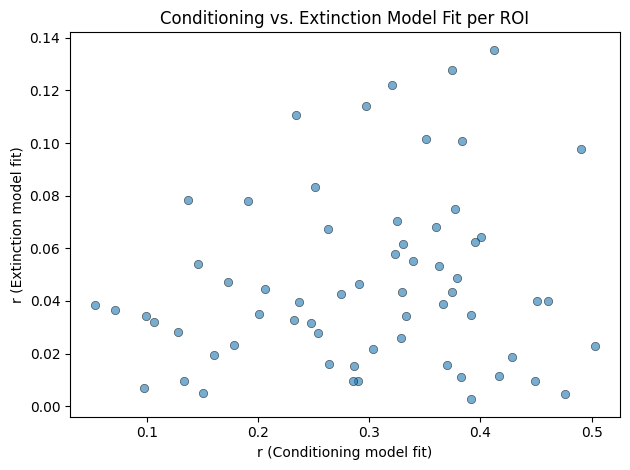

In [54]:
#created a scatter plot with r_index_conditioning on the x-axis, and r_index_extinctino on the y axis and labeled my axes

import matplotlib.pyplot as plt

plt.scatter(r_model_conditioning, r_index_extinction, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.xlabel('r (Conditioning model fit)')
plt.ylabel('r (Extinction model fit)')
plt.title('Conditioning vs. Extinction Model Fit per ROI')
plt.tight_layout()
plt.show()

Based on the correlation coefficient and the pvalue, there does not seem to be a signitficant relationship between how strongly a cell responds to shock and tone onset. The p-value is well above 0.05 meaning that our data is not significant. This is shown in the plot as well as it looks to be random the way that the cells on the plot are placed with no clear direction.